## Step 1: Import libraries

- Load core data, plotting, and ML libraries
- Enable inline charts for notebook visuals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Step 2: Load dataset

- Read the CSV into DataFrame `df`
- Use the local path `datasets/TS-PS12.csv`

In [2]:
df = pd.read_csv('datasets/TS-PS12.csv')

## Step 3: Dataset profiling

- Summarize shape, missing values, and unique counts
- Show numeric and categorical statistics
- Display the target distribution

In [3]:
from IPython.display import display

if "df" not in globals():
    df = pd.read_csv("datasets/TS-PS12.csv")

row_count, col_count = df.shape
cell_count = row_count * col_count
missing_total = int(df.isna().sum().sum())
missing_pct = round((missing_total / cell_count) * 100, 2) if cell_count else 0

overview = pd.DataFrame(
    [
        {
            "rows": row_count,
            "columns": col_count,
            "duplicate_rows": int(df.duplicated().sum()),
            "total_missing": missing_total,
            "missing_pct": missing_pct,
        }
    ]
)

display(overview)
display(df.head(5))

col_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "nulls": df.isna().sum(),
        "null_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
        "unique_pct": (df.nunique(dropna=True) / row_count * 100).round(2),
    }
).sort_index()

display(col_summary)

numeric_cols = df.select_dtypes(include="number")
if not numeric_cols.empty:
    numeric_stats = numeric_cols.describe().T
    numeric_stats["median"] = numeric_cols.median()
    numeric_stats["range"] = numeric_cols.max() - numeric_cols.min()
    numeric_stats = numeric_stats[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "median", "range"]
    ]
    display(numeric_stats)

categorical_cols = df.select_dtypes(exclude="number")
if not categorical_cols.empty:
    cat_stats = pd.DataFrame(
        {
            "unique": categorical_cols.nunique(dropna=True),
            "top": categorical_cols.mode().iloc[0],
            "top_freq": categorical_cols.apply(
                lambda s: s.value_counts(dropna=False).iloc[0]
            ),
            "top_pct": (
                categorical_cols.apply(
                    lambda s: s.value_counts(dropna=False).iloc[0]
                )
                / row_count
                * 100
            ).round(2),
        }
    )
    display(cat_stats)

if "risk_label" in df.columns:
    risk_dist = pd.DataFrame(
        {
            "count": df["risk_label"].value_counts(dropna=False),
            "pct": (
                df["risk_label"].value_counts(normalize=True, dropna=False) * 100
            ).round(2),
        }
    )
    display(risk_dist)


,rows,columns,duplicate_rows,total_missing,missing_pct
0,50000,7,0,0,0.0


,student_id,attendance,marks,assignment,lms,risk_score,risk_label
0,1,84,96,34,20,28.8,Low
1,2,87,72,87,28,23.4,Low
2,3,93,87,95,26,15.1,Low
3,4,40,66,83,52,42.4,Medium
4,5,43,99,50,75,35.6,Medium


,dtype,non_null,nulls,null_pct,unique,unique_pct
assignment,int64,50000,0,0.0,70,0.14
attendance,int64,50000,0,0.0,60,0.12
lms,int64,50000,0,0.0,80,0.16
marks,int64,50000,0,0.0,70,0.14
risk_label,str,50000,0,0.0,3,0.01
risk_score,float64,50000,0,0.0,591,1.18
student_id,int64,50000,0,0.0,50000,100.00


,count,mean,std,min,25%,50%,75%,max,median,range
student_id,50000.0,25000.50000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0,25000.5,49999.0
attendance,50000.0,69.65930,17.312073,40.0,55.00,70.0,85.00,99.0,70.0,59.0
marks,50000.0,64.53546,20.216269,30.0,47.00,65.0,82.00,99.0,65.0,69.0
assignment,50000.0,64.45042,20.186077,30.0,47.00,65.0,82.00,99.0,65.0,69.0
lms,50000.0,59.35738,23.092708,20.0,39.00,59.0,79.00,99.0,59.0,79.0
risk_score,50000.0,33.94982,10.335702,3.2,26.60,34.0,41.20,65.2,34.0,62.0


,unique,top,top_freq,top_pct
risk_label,3,Medium,31990,63.98


,count,pct
risk_label,,
Medium,31990,63.98
Low,17899,35.80
High,111,0.22


# Dataset overview (TS-PS12.csv)

**Location:** datasets/TS-PS12.csv  
**Rows:** 50000  
**Columns:** 7  
**Missing values:** 0 (0.0%)  
**Duplicate rows:** 0  
**Target:** risk_label (Low, Medium, High)

## Use case

Predict student academic risk as Low, Medium, or High using engagement and performance signals.

## Feature dictionary

| feature | type | description | notes |
| --- | --- | --- | --- |
| assignment | int64 | Assignment performance score | 0-100 scale; 70 unique values |
| attendance | int64 | Attendance score | 0-100 scale; 60 unique values |
| lms | int64 | LMS engagement score | 0-100 scale; 80 unique values |
| marks | int64 | Exam/assessment marks | 0-100 scale; 70 unique values |
| risk_score | float64 | Composite risk score | 3.2-65.2; 591 unique values |
| student_id | int64 | Unique student identifier | Drop before modeling |
| risk_label | str | Target class | Low, Medium, High |

## Data quality and balance

- No missing values and no duplicate rows.
- Class imbalance: High is 0.22% of rows.

## Modeling notes

- Drop `student_id` before training.
- Use class-weighted models or resampling to handle imbalance.
- Scale features for linear models (Logistic Regression).

## Risk label distribution

| label | count | pct |
| --- | --- | --- |
| Medium | 31990 | 63.98 |
| Low | 17899 | 35.80 |
| High | 111 | 0.22 |

## Numeric feature summary

| feature | min | p25 | median | mean | p75 | max | std | range |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| student_id | 1.0 | 12500.75 | 25000.5 | 25000.5 | 37500.25 | 50000.0 | 14433.901067 | 49999.0 |
| attendance | 40.0 | 55.0 | 70.0 | 69.65930 | 85.0 | 99.0 | 17.312073 | 59.0 |
| marks | 30.0 | 47.0 | 65.0 | 64.53546 | 82.0 | 99.0 | 20.216269 | 69.0 |
| assignment | 30.0 | 47.0 | 65.0 | 64.45042 | 82.0 | 99.0 | 20.186077 | 69.0 |
| lms | 20.0 | 39.0 | 59.0 | 59.35738 | 79.0 | 99.0 | 23.092708 | 79.0 |
| risk_score | 3.2 | 26.6 | 34.0 | 33.94982 | 41.2 | 65.2 | 10.335702 | 62.0 |


## Step 4: Encode target labels

- Convert `risk_label` to numeric classes
- Store the encoder in `le` for reuse

In [4]:
# Label Encoding the Risk Labels

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['risk_label'] = le.fit_transform(df['risk_label'])

# Higher the number, higher the risk

## Step 5: Drop identifier

- Remove `student_id` to prevent leakage
- Keep only predictive features

In [5]:
df = df.drop("student_id", axis = 1)

## Step 6: Define features and target

- Create `X` for features
- Create `y` for the target label

In [6]:
X = df.drop("risk_label", axis = 1)
y = df["risk_label"]

## Step 7: Train-test split

- Stratify to keep class balance
- Fix `random_state` for reproducibility

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

## Modeling: baselines and ensembles

We start with a simple baseline (Logistic Regression) and then compare multiple ensemble models. Metrics include accuracy, balanced accuracy, and F1 scores to account for class imbalance.

## Step 8: Train and compare models

- Train baseline and ensemble models
- Evaluate accuracy, balanced accuracy, and F1
- Rank models by F1-macro

In [12]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)

if "X" not in globals() or "y" not in globals():
    X = df.drop("risk_label", axis=1)
    y = df["risk_label"]

if y.dtype == "object" or str(y.dtype).startswith("category"):
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    y = le.fit_transform(y)

if "X_train" not in globals():
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y,
    )

try:
    from xgboost import XGBClassifier

    xgb_available = True
except Exception as exc:
    xgb_available = False
    print(f"XGBoost not available: {exc}")


def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
        "f1_macro": f1_score(y_test, preds, average="macro"),
        "f1_weighted": f1_score(y_test, preds, average="weighted"),
    }, preds, model


models = []

# Scale features for Logistic Regression to improve convergence.
log_reg = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="lbfgs",
            ),
        ),
    ]
)
models.append(("Logistic Regression", log_reg))

models.append(
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
        ),
    )
)

models.append(
    (
        "Extra Trees",
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
        ),
    )
)

models.append(
    (
        "Gradient Boosting",
        GradientBoostingClassifier(random_state=42),
    )
)

models.append(
    (
        "AdaBoost",
        AdaBoostClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=42,
        ),
    )
)

if xgb_available:
    num_classes = len(np.unique(y))
    xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss",
        tree_method="hist",
    )
    models.append(("XGBoost", xgb))

results = []
preds_map = {}
fitted_models = {}

for name, model in models:
    metrics, preds, fitted = evaluate_model(name, model)
    results.append(metrics)
    preds_map[name] = preds
    fitted_models[name] = fitted

results_df = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values("f1_macro", ascending=False)
)
results_df

,accuracy,balanced_accuracy,f1_macro,f1_weighted
model,,,,
AdaBoost,0.999267,0.989552,0.994371,0.999266
Gradient Boosting,0.998933,0.999280,0.984826,0.998938
Random Forest,0.998600,0.948775,0.962164,0.998589
Extra Trees,0.997667,0.948043,0.961486,0.997656
XGBoost,0.998133,0.908185,0.919745,0.998110
Logistic Regression,0.991800,0.995728,0.847232,0.992576


## Best model details

We pick the top model by macro F1, then show its classification report and confusion matrix.

## Step 9: Best model report

- Print best-model metrics and parameters
- Show classification report and confusion matrix

Best model by F1-macro: AdaBoost
              precision    recall  f1-score   support

           0     1.0000    0.9697    0.9846        33
           1     0.9981    1.0000    0.9991      5370
           2     0.9999    0.9990    0.9994      9597

    accuracy                         0.9993     15000
   macro avg     0.9993    0.9896    0.9944     15000
weighted avg     0.9993    0.9993    0.9993     15000



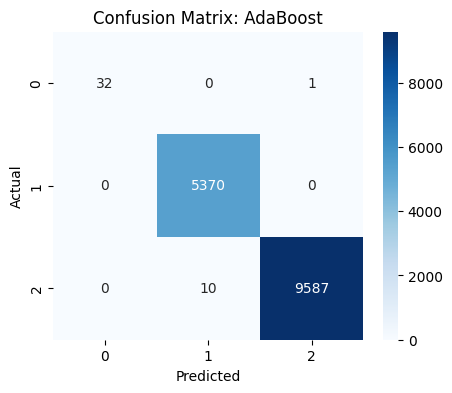

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
best_preds = preds_map[best_model_name]

print(f"Best model by F1-macro: {best_model_name}")
print("Best model metrics:")
print(results_df.loc[best_model_name])

print("\nModel type:", type(best_model).__name__)
try:
    print("Model params:", best_model.get_params())
except Exception:
    print("Model params: unavailable")

print("\nClassification report:")
print(classification_report(y_test, best_preds, digits=4))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Export best model (.pkl)

Save the top model to a pickle file and generate a download link from the notebook.

## Step 10: Export best model

- Save `best_model.pkl`
- Save `label_encoder.pkl` when available
- Provide download links

In [11]:
import joblib
from IPython.display import FileLink, display

if "results_df" not in globals() or "fitted_models" not in globals():
    raise RuntimeError("Run the modeling cell to train models before exporting.")

best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]

model_path = "best_model.pkl"
joblib.dump(best_model, model_path)

encoder_path = None
if "le" in globals():
    encoder_path = "label_encoder.pkl"
    joblib.dump(le, encoder_path)

print(f"Saved model to {model_path}")
display(FileLink(model_path))

if encoder_path:
    print(f"Saved label encoder to {encoder_path}")
    display(FileLink(encoder_path))


Saved model to best_model.pkl


c:\Users\Yashesh Mehta\Desktop\Tark Shastra 2026\ml application\best_model.pkl

Saved label encoder to label_encoder.pkl


c:\Users\Yashesh Mehta\Desktop\Tark Shastra 2026\ml application\label_encoder.pkl

## Step 11: Optional scratch cell

- Use this space for extra checks or experiments

## Conclusion and system summary

### System summary

- Goal: predict academic risk (Low, Medium, High) from engagement and performance signals.
- Data: 50,000 rows, 7 columns, no missing values; strong class imbalance for the High class.
- Pipeline: label encoding, feature selection (drop `student_id`), stratified split, model comparison, best-model report, and export.
- Deployment path: exported `.pkl` model can be served by the ML API and consumed by the Core API.

### Model summary

- Baseline: Logistic Regression (scaled features, class-balanced).
- Ensembles: Random Forest, Extra Trees, Gradient Boosting, AdaBoost, and optional XGBoost.
- Selection: best model chosen by macro F1 to balance performance across all classes.
- Outputs: classification report, confusion matrix, and downloadable model artifacts.